# ConvLSTM — fast ablations and final config



In [1]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from skimage.metrics import structural_similarity as ssim_metric
import time, warnings
warnings.filterwarnings("ignore")

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device :", DEVICE)
if DEVICE.type == "cuda":
    print("GPU    :", torch.cuda.get_device_name(0))

# Fast by default
FAST_MODE = True

if FAST_MODE:
    N_TRAIN = 200
    N_VAL = 50
    N_EPOCHS = 8
else:
    N_TRAIN = 500
    N_VAL = 100
    N_EPOCHS = 30

IMG_SIZE = 32
N_INPUT = 10
N_OUTPUT = 10
BATCH_SIZE = 8
LR = 1e-3

# Main candidate from the fast search
BEST_KERNEL = 3
BEST_ALPHA = 0.7
BEST_TF_START = 1.0
BEST_TF_END = 0.3
BEST_PEEPHOLE = True

# Optional
RUN_KERNEL_RERUN = True   # reruns kernel 1/3/5 under the slower TF schedule
RUN_ALPHA_CHECK = True    # checks alpha=0.5 vs alpha=0.7 under the slower TF schedule


PyTorch: 2.10.0+cu128
Device : cuda
GPU    : Tesla T4


## Dataset

In [2]:

class MovingBlobDataset(Dataset):
    def __init__(self, n_samples=600, n_input=10, n_output=10,
                 img_size=32, n_blobs=2, seed=0):
        self.n_input = n_input
        self.n_output = n_output
        self.img_size = img_size
        rng = np.random.RandomState(seed)
        self.sequences = self._build(n_samples, rng, n_blobs)

    @staticmethod
    def _blob(size, cx, cy, sigma):
        xs, ys = np.arange(size), np.arange(size)
        xx, yy = np.meshgrid(xs, ys)
        return np.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2 * sigma ** 2))

    def _build(self, N, rng, n_blobs):
        S = self.img_size
        T = self.n_input + self.n_output
        seqs = []
        for _ in range(N):
            seq = np.zeros((T, 1, S, S), dtype=np.float32)
            pos = rng.uniform(5, S - 5, (n_blobs, 2))
            vel = rng.uniform(-2.5, 2.5, (n_blobs, 2))
            sigmas = rng.uniform(2.5, 4.5, n_blobs)

            for t in range(T):
                frame = np.zeros((S, S), dtype=np.float32)
                for d in range(n_blobs):
                    frame += self._blob(S, pos[d, 0], pos[d, 1], sigmas[d])
                    pos[d] += vel[d]
                    for dim in range(2):
                        if pos[d, dim] < 4:
                            pos[d, dim] = 4
                            vel[d, dim] = abs(vel[d, dim])
                        elif pos[d, dim] > S - 4:
                            pos[d, dim] = S - 4
                            vel[d, dim] = -abs(vel[d, dim])
                seq[t, 0] = np.clip(frame, 0, 1)
            seqs.append(seq)
        return np.stack(seqs)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = torch.from_numpy(self.sequences[idx])
        return seq[:self.n_input], seq[self.n_input:]


def make_loaders(n_train=N_TRAIN, n_val=N_VAL):
    train_ds = MovingBlobDataset(n_samples=n_train, n_input=N_INPUT, n_output=N_OUTPUT,
                                 img_size=IMG_SIZE, seed=SEED)
    val_ds = MovingBlobDataset(n_samples=n_val, n_input=N_INPUT, n_output=N_OUTPUT,
                               img_size=IMG_SIZE, seed=SEED + 99)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    return train_ds, val_ds, train_loader, val_loader

train_ds, val_ds, train_loader, val_loader = make_loaders()
x0, y0 = train_ds[0]
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")
print("Input shape :", tuple(x0.shape))
print("Target shape:", tuple(y0.shape))


Train: 200 | Val: 50
Input shape : (10, 1, 32, 32)
Target shape: (10, 1, 32, 32)


## Model

In [3]:
class ConvLSTMCell(nn.Module):
    """
    ConvLSTM cell — faithful implementation of Equation (3), Shi et al. 2015.

    Key design choices
    ------------------
    1. Fused convolution: all four gates [i, f, g, o] are computed in one
       Conv2d over [X_t || H_{t-1}] concatenated along the channel axis.
       This is algebraically equivalent to four separate convolutions but
       faster in practice (one kernel launch instead of four).

    2. Peephole connections: W_ci, W_cf, W_co are learnable elementwise
       weights (not convolutions) that let the gates observe the cell state
       directly, as written in Eq. (3).

    3. Same-padding: kernel_size // 2 padding keeps (H, W) unchanged after
       every convolution, which the paper requires.

    4. Forget-gate bias initialised to 1: a common trick that prevents the
       network from forgetting everything at the very start of training.
    """

    def __init__(self, in_channels: int, hidden_channels: int,
                 kernel_size: int = 5, bias: bool = True,
                 peephole: bool = True):
        """
        Parameters
        ----------
        in_channels     : C of input tensor X_t
        hidden_channels : number of hidden feature maps
        kernel_size     : spatial conv kernel (paper: 5×5 for Moving MNIST)
        bias            : add bias terms to conv
        peephole        : include W_ci / W_cf / W_co peephole weights
        """
        super().__init__()
        self.hidden_channels = hidden_channels
        self.use_peephole    = peephole
        pad = kernel_size // 2

        # Single fused conv: maps [X_t || H_{t-1}] -> [i, f, g, o] stacked
        self.conv = nn.Conv2d(
            in_channels  = in_channels + hidden_channels,
            out_channels = 4 * hidden_channels,
            kernel_size  = kernel_size,
            padding      = pad,
            bias         = bias
        )
        nn.init.xavier_uniform_(self.conv.weight)
        if bias:
            nn.init.zeros_(self.conv.bias)
            # Forget gate bias → 1 to start with near-full memory retention
            nn.init.ones_(self.conv.bias[hidden_channels: 2 * hidden_channels])

        # ── Peephole weights ──────────────────────────────────────────────
        # Shape: (1, hidden_channels, 1, 1) so they broadcast over (B, C, H, W)
        # without knowing H and W at construction time.
        # Note: W_co peeks at C_t (after update), not C_{t-1}.
        if self.use_peephole:
            self.W_ci = nn.Parameter(torch.zeros(1, hidden_channels, 1, 1))
            self.W_cf = nn.Parameter(torch.zeros(1, hidden_channels, 1, 1))
            self.W_co = nn.Parameter(torch.zeros(1, hidden_channels, 1, 1))
            nn.init.normal_(self.W_ci, std=0.01)
            nn.init.normal_(self.W_cf, std=0.01)
            nn.init.normal_(self.W_co, std=0.01)

    def zero_state(self, batch_size: int, height: int, width: int, device):
        """Return zero-initialised (H_0, C_0) — 'total ignorance' per the paper."""
        z = torch.zeros(batch_size, self.hidden_channels, height, width, device=device)
        return z, z.clone()

    def forward(self, x: torch.Tensor, state=None):
        """
        One timestep of the ConvLSTM cell.

        Parameters
        ----------
        x     : (B, in_channels, H, W)   current input X_t
        state : (H_{t-1}, C_{t-1}) or None  (None → zero-initialise)

        Returns
        -------
        h_t        : (B, hidden_channels, H, W)
        (h_t, c_t) : updated state tuple
        """
        B, _, H, W = x.shape
        if state is None:
            h_prev, c_prev = self.zero_state(B, H, W, x.device)
        else:
            h_prev, c_prev = state

        # ── Step 1: fused convolution ─────────────────────────────────────
        # Concatenate input and previous hidden state along channel axis,
        # then compute all four gate pre-activations in one shot.
        combined = torch.cat([x, h_prev], dim=1)   # (B, in_ch+hid_ch, H, W)
        gates    = self.conv(combined)              # (B, 4*hid_ch, H, W)

        # Split into four gate tensors
        i_raw, f_raw, g_raw, o_raw = torch.chunk(gates, 4, dim=1)

        # ── Step 2: peephole additions ────────────────────────────────────
        # i and f peek at C_{t-1}; o will peek at C_t (computed below)
        if self.use_peephole:
            i_raw = i_raw + self.W_ci * c_prev
            f_raw = f_raw + self.W_cf * c_prev

        # ── Step 3: gate activations ──────────────────────────────────────
        i_t = torch.sigmoid(i_raw)   # input gate  — what to write
        f_t = torch.sigmoid(f_raw)   # forget gate — what to erase
        g_t = torch.tanh(g_raw)      # cell gate   — candidate content

        # ── Step 4: cell state update ─────────────────────────────────────
        c_t = f_t * c_prev + i_t * g_t

        # ── Step 5: output gate (peeks at updated C_t) ────────────────────
        if self.use_peephole:
            o_raw = o_raw + self.W_co * c_t
        o_t = torch.sigmoid(o_raw)

        # ── Step 6: hidden state ──────────────────────────────────────────
        h_t = o_t * torch.tanh(c_t)

        return h_t, (h_t, c_t)


# Quick shape sanity check
_c   = ConvLSTMCell(in_channels=1, hidden_channels=32, kernel_size=5, peephole=True).to(DEVICE)
_x   = torch.randn(2, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
_h, (_h2, _c2) = _c(_x)
print(f'ConvLSTMCell (with peepholes): output shape = {_h.shape}  ✓')
del _c, _x, _h, _h2, _c2

ConvLSTMCell (with peepholes): output shape = torch.Size([2, 32, 32, 32])  ✓


In [4]:
class EncoderBlock(nn.Module):
    """
    One stage of the encoding network:
      1. Optional strided convolution to downsample spatial resolution.
      2. A ConvLSTMCell that processes the downsampled sequence step by step.

    Returns the full sequence of hidden states (fed to the next stage)
    and the final (h, c) pair (copied to the corresponding decoder stage).
    """

    def __init__(self, in_ch: int, hid_ch: int,
                 kernel_size: int = 5, stride: int = 1,
                 peephole: bool = True):
        super().__init__()
        # Strided conv: stride=1 → same size, stride=2 → halve H and W
        self.proj = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(in_ch),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.cell = ConvLSTMCell(in_ch, hid_ch, kernel_size, peephole=peephole)

    def forward(self, seq):  # seq: (T, B, C, H, W)
        state   = None
        outputs = []
        for t in range(seq.shape[0]):
            xt       = self.proj(seq[t])
            h, state = self.cell(xt, state)
            outputs.append(h)
        return torch.stack(outputs), state  # (T, B, hid_ch, H', W'), final state


class EncodingNetwork(nn.Module):
    """
    Full stacked encoding network (Figure 3, left).

    Architecture:
        Stage 0: stride=1  →  32×32,  16 hidden maps
        Stage 1: stride=2  →  16×16,  32 hidden maps
        Stage 2: stride=2  →   8×8,   64 hidden maps
    """

    def __init__(self, kernel_size: int = 5, peephole: bool = True):
        super().__init__()
        self.stages = nn.ModuleList([
            EncoderBlock(in_ch= 1, hid_ch=16, kernel_size=kernel_size, stride=1, peephole=peephole),
            EncoderBlock(in_ch=16, hid_ch=32, kernel_size=kernel_size, stride=2, peephole=peephole),
            EncoderBlock(in_ch=32, hid_ch=64, kernel_size=kernel_size, stride=2, peephole=peephole),
        ])

    def forward(self, x: torch.Tensor):
        """
        Parameters
        ----------
        x : (B, T, 1, H, W)   input sequence

        Returns
        -------
        enc_states : list of final (h, c) per stage  [shallowest → deepest]
        """
        seq = x.permute(1, 0, 2, 3, 4)   # → (T, B, 1, H, W)
        enc_states = []
        for stage in self.stages:
            seq, state = stage(seq)
            enc_states.append(state)
        return enc_states   # [(h0,c0), (h1,c1), (h2,c2)]


print('EncodingNetwork defined.')

EncodingNetwork defined.


In [5]:
class ForecastingNetwork(nn.Module):
    """
    Stacked ConvLSTM forecasting network (Figure 3, right).

    Initialised from encoder hidden states (the 'Copy' operation in Fig. 3).
    Unrolls for n_output steps to produce the predicted sequence.

    Implements scheduled sampling: at each step, the frame fed to the
    next step is either the ground truth (probability = teacher_forcing_ratio)
    or the model's own prediction (probability = 1 - teacher_forcing_ratio).

    Architecture mirrors the encoder in reverse:
        Stage 0:  8× 8,  64 hidden maps  → upsample →  16×16, 32 ch
        Stage 1: 16×16,  32 hidden maps  → upsample →  32×32, 16 ch
        Stage 2: 32×32,  16 hidden maps  → 1×1 conv →       1 ch
    """

    def __init__(self, kernel_size: int = 5, n_output: int = 10,
                 peephole: bool = True):
        super().__init__()
        self.n_output = n_output

        # ConvLSTM cells — deepest encoder state feeds stage 0
        self.cells = nn.ModuleList([
            ConvLSTMCell(64, 64, kernel_size, peephole=peephole),  # 8×8
            ConvLSTMCell(32, 32, kernel_size, peephole=peephole),  # 16×16
            ConvLSTMCell(16, 16, kernel_size, peephole=peephole),  # 32×32
        ])

        # Upsampling between stages
        self.upsamplers = nn.ModuleList([
            nn.Sequential(
                nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(32),
                nn.LeakyReLU(0.2, inplace=True)
            ),
            nn.Sequential(
                nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(16),
                nn.LeakyReLU(0.2, inplace=True)
            ),
        ])

        # Final projection: 16 hidden maps → 1 output channel in [0,1]
        self.output_head = nn.Sequential(
            nn.Conv2d(16, 1, kernel_size=1),
            nn.Sigmoid()
        )

        # Projection to feed predicted frame back into deepest cell
        # (predicted frame is 1-channel at 32×32; we need 64-ch at 8×8)
        self.feedback_proj = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, enc_states: list,
                target_seq=None, teacher_forcing_ratio: float = 1.0):
        """
        Parameters
        ----------
        enc_states           : [(h2,c2),(h1,c1),(h0,c0)] — deepest first
        target_seq           : (B, n_output, 1, H, W) ground truth (train only)
        teacher_forcing_ratio: probability of using ground truth at each step

        Returns
        -------
        predictions : (B, n_output, 1, H, W)
        """
        # enc_states arrives [shallowest→deepest]; we need [deepest→shallowest]
        states = list(reversed(enc_states))  # [deep, mid, shallow]

        B, _, H8, W8 = states[0][0].shape   # 8×8 spatial at deepest layer

        # Start token: zero tensor at the deepest spatial resolution
        x_in = torch.zeros(B, 64, H8, W8, device=states[0][0].device)

        predictions = []

        for t in range(self.n_output):

            # ── Stage 0: deepest layer (8×8) ─────────────────────────────
            h0, states[0] = self.cells[0](x_in, states[0])
            up0 = self.upsamplers[0](h0)          # → (B, 32, 16, 16)

            # ── Stage 1: middle layer (16×16) ────────────────────────────
            h1, states[1] = self.cells[1](up0, states[1])
            up1 = self.upsamplers[1](h1)          # → (B, 16, 32, 32)

            # ── Stage 2: shallowest layer (32×32) ────────────────────────
            h2, states[2] = self.cells[2](up1, states[2])

            # ── Output frame ──────────────────────────────────────────────
            frame = self.output_head(h2)           # (B, 1, 32, 32)
            predictions.append(frame)

            # ── Scheduled sampling: choose next input ─────────────────────
            # During training, flip a coin: heads → use ground truth,
            # tails → use the frame we just predicted.
            # During evaluation, always use our own prediction (ratio=0).
            use_gt = (
                target_seq is not None
                and t < self.n_output - 1
                and torch.rand(1).item() < teacher_forcing_ratio
            )
            next_frame = target_seq[:, t] if use_gt else frame
            x_in = self.feedback_proj(next_frame)  # project back to 8×8, 64-ch

        return torch.stack(predictions, dim=1)   # (B, n_output, 1, H, W)


print('ForecastingNetwork defined.')

ForecastingNetwork defined.


In [6]:
class ConvLSTMModel(nn.Module):
    """
    End-to-end Encoding-Forecasting ConvLSTM (Figure 3, Shi et al. 2015)
    with peephole connections and scheduled sampling support.
    """

    def __init__(self, kernel_size: int = 5, n_output: int = 10,
                 peephole: bool = True):
        super().__init__()
        self.encoder    = EncodingNetwork(kernel_size=kernel_size, peephole=peephole)
        self.forecaster = ForecastingNetwork(kernel_size=kernel_size,
                                             n_output=n_output, peephole=peephole)

    def forward(self, x: torch.Tensor,
                target_seq=None, teacher_forcing_ratio: float = 1.0):
        """
        Parameters
        ----------
        x                    : (B, T_in, 1, H, W)   input sequence
        target_seq           : (B, T_out, 1, H, W)  ground truth (training only)
        teacher_forcing_ratio: scheduled sampling ratio in [0, 1]

        Returns
        -------
        preds : (B, T_out, 1, H, W)
        """
        enc_states = self.encoder(x)
        preds      = self.forecaster(enc_states, target_seq, teacher_forcing_ratio)
        return preds


# Instantiate and verify shapes
model = ConvLSTMModel(kernel_size=5, n_output=N_OUTPUT, peephole=True).to(DEVICE)

with torch.no_grad():
    _x   = torch.randn(2, N_INPUT,  1, IMG_SIZE, IMG_SIZE).to(DEVICE)
    _y   = torch.randn(2, N_OUTPUT, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
    _out = model(_x, _y, teacher_forcing_ratio=1.0)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model OK')
print(f'  Input  shape : {_x.shape}')
print(f'  Output shape : {_out.shape}')
print(f'  Trainable parameters: {n_params:,}')
del _x, _y, _out

Model OK
  Input  shape : torch.Size([2, 10, 1, 32, 32])
  Output shape : torch.Size([2, 10, 1, 32, 32])
  Trainable parameters: 1,943,388


In [7]:
def gaussian_window(window_size: int, sigma: float, device) -> torch.Tensor:
    """
    1D Gaussian kernel of given size and sigma.
    Used to build a 2D separable smoothing filter for SSIM.
    """
    coords = torch.arange(window_size, dtype=torch.float32, device=device)
    coords -= window_size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    return g / g.sum()


def ssim_loss(pred: torch.Tensor, target: torch.Tensor,
              window_size: int = 7, sigma: float = 1.5,
              C1: float = 0.01 ** 2, C2: float = 0.03 ** 2) -> torch.Tensor:
    """
    Differentiable SSIM loss: returns 1 - mean SSIM over the batch.

    Both pred and target are expected in [0, 1].
    Works on (B, C, H, W) or (B, T, C, H, W) — flattens time into batch.

    Parameters
    ----------
    window_size : size of the Gaussian smoothing kernel (must be odd)
    sigma       : Gaussian sigma for the smoothing kernel
    C1, C2      : stability constants from the SSIM formula
    """
    # Flatten time dimension if present
    if pred.dim() == 5:   # (B, T, C, H, W)
        B, T, C, H, W = pred.shape
        pred   = pred.view(B * T, C, H, W)
        target = target.view(B * T, C, H, W)

    # Build 2D Gaussian kernel from outer product of two 1D kernels
    g    = gaussian_window(window_size, sigma, pred.device)
    ker2 = torch.outer(g, g).unsqueeze(0).unsqueeze(0)  # (1,1,ws,ws)
    C_ch = pred.shape[1]
    ker2 = ker2.expand(C_ch, 1, window_size, window_size)

    pad = window_size // 2
    conv_kw = dict(padding=pad, groups=C_ch)

    mu_x  = F.conv2d(pred,   ker2, **conv_kw)
    mu_y  = F.conv2d(target, ker2, **conv_kw)
    mu_x2 = mu_x ** 2
    mu_y2 = mu_y ** 2
    mu_xy = mu_x * mu_y

    sigma_x2  = F.conv2d(pred   ** 2, ker2, **conv_kw) - mu_x2
    sigma_y2  = F.conv2d(target ** 2, ker2, **conv_kw) - mu_y2
    sigma_xy  = F.conv2d(pred * target, ker2, **conv_kw) - mu_xy

    num = (2 * mu_xy  + C1) * (2 * sigma_xy  + C2)
    den = (mu_x2 + mu_y2 + C1) * (sigma_x2 + sigma_y2 + C2)

    ssim_map = num / (den + 1e-8)
    return 1.0 - ssim_map.mean()


def combined_loss(pred: torch.Tensor, target: torch.Tensor,
                  alpha: float = 0.7) -> torch.Tensor:
    """
    Weighted combination: alpha * MSE + (1-alpha) * (1 - SSIM)

    alpha=1.0 → pure MSE (baseline)
    alpha=0.0 → pure SSIM loss
    alpha=0.7 → our default: majority MSE, minority structural penalty
    """
    mse  = F.mse_loss(pred, target)
    ssim = ssim_loss(pred, target)
    return alpha * mse + (1.0 - alpha) * ssim


# Quick test
_p = torch.rand(2, N_OUTPUT, 1, IMG_SIZE, IMG_SIZE)
_t = torch.rand(2, N_OUTPUT, 1, IMG_SIZE, IMG_SIZE)
print(f'Combined loss on random tensors: {combined_loss(_p, _t).item():.5f}')
print(f'  (should be non-zero and positive)')
del _p, _t

Combined loss on random tensors: 0.38070
  (should be non-zero and positive)


## Training and evaluation

In [8]:

def get_teacher_forcing_ratio(epoch, n_epochs, tf_start=1.0, tf_end=0.0):
    if n_epochs == 1:
        return tf_end
    frac = (epoch - 1) / (n_epochs - 1)
    return tf_start + frac * (tf_end - tf_start)


def train_model(model, train_loader, val_loader, n_epochs=N_EPOCHS, lr=LR,
                alpha=0.7, tf_start=1.0, tf_end=0.0, tag="run"):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-5)

    best_val_loss = float("inf")
    best_weights = None
    history = {"train_loss": [], "val_loss": [], "tf_ratio": []}
    t0 = time.time()

    for epoch in range(1, n_epochs + 1):
        tf_ratio = get_teacher_forcing_ratio(epoch, n_epochs, tf_start, tf_end)
        history["tf_ratio"].append(tf_ratio)

        model.train()
        epoch_loss = 0.0
        for x_b, y_b in train_loader:
            x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            pred = model(x_b, target_seq=y_b, teacher_forcing_ratio=tf_ratio)
            loss = combined_loss(pred, y_b, alpha=alpha)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        train_loss = epoch_loss / len(train_loader)
        history["train_loss"].append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_b, y_b in val_loader:
                x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
                pred = model(x_b, teacher_forcing_ratio=0.0)
                val_loss += combined_loss(pred, y_b, alpha=alpha).item()

        val_loss /= len(val_loader)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = {k: v.detach().clone() for k, v in model.state_dict().items()}

        scheduler.step()
        print(f"{tag:>16} | Epoch {epoch:02d}/{n_epochs} | Train {train_loss:.4f} | Val {val_loss:.4f} | TF {tf_ratio:.2f}")

    model.load_state_dict(best_weights)
    minutes = (time.time() - t0) / 60.0
    return history, best_val_loss, minutes


def evaluate(model, loader):
    model.eval()
    total_mse = 0.0
    total_ssim = 0.0
    n_frames = 0

    with torch.no_grad():
        for x_b, y_b in loader:
            x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
            pred = model(x_b, teacher_forcing_ratio=0.0)

            total_mse += F.mse_loss(pred, y_b, reduction="sum").item()

            pred_np = pred.cpu().numpy()
            gt_np = y_b.cpu().numpy()
            B, T = pred_np.shape[:2]
            for b in range(B):
                for t in range(T):
                    total_ssim += ssim_metric(pred_np[b, t, 0], gt_np[b, t, 0], data_range=1.0)
                    n_frames += 1

    mean_mse = total_mse / (n_frames * IMG_SIZE * IMG_SIZE)
    mean_ssim = total_ssim / n_frames
    return mean_mse, mean_ssim


def per_timestep_metrics(model, loader):
    model.eval()
    mse_per_t = np.zeros(N_OUTPUT)
    ssim_per_t = np.zeros(N_OUTPUT)
    n_items = 0

    with torch.no_grad():
        for x_b, y_b in loader:
            pred = model(x_b.to(DEVICE), teacher_forcing_ratio=0.0).cpu().numpy()
            gt = y_b.numpy()
            B = pred.shape[0]
            for t in range(N_OUTPUT):
                mse_per_t[t] += ((pred[:, t] - gt[:, t]) ** 2).mean()
                for b in range(B):
                    ssim_per_t[t] += ssim_metric(pred[b, t, 0], gt[b, t, 0], data_range=1.0)
            n_items += B

    return mse_per_t / len(loader), ssim_per_t / n_items


## Fast experiments

In [9]:

def run_experiment(name, kernel=3, alpha=0.7, tf_start=1.0, tf_end=0.0, peephole=True):
    model = ConvLSTMModel(kernel_size=kernel, n_output=N_OUTPUT, peephole=peephole).to(DEVICE)
    history, best_val_loss, minutes = train_model(
        model, train_loader, val_loader, n_epochs=N_EPOCHS, lr=LR,
        alpha=alpha, tf_start=tf_start, tf_end=tf_end, tag=name
    )
    val_mse, val_ssim = evaluate(model, val_loader)
    return {
        "name": name,
        "kernel": kernel,
        "alpha": alpha,
        "tf_start": tf_start,
        "tf_end": tf_end,
        "peephole": peephole,
        "best_val_loss": best_val_loss,
        "val_mse": val_mse,
        "val_ssim": val_ssim,
        "minutes": minutes,
        "history": history,
        "model": model,
    }

experiments = []
experiments.append(run_experiment("baseline_k3", kernel=3, alpha=0.7, tf_start=1.0, tf_end=0.0, peephole=True))
experiments.append(run_experiment("tf_slow_decay", kernel=3, alpha=0.7, tf_start=1.0, tf_end=0.3, peephole=True))
experiments.append(run_experiment("alpha_half", kernel=3, alpha=0.5, tf_start=1.0, tf_end=0.3, peephole=True) if RUN_ALPHA_CHECK else None)
experiments.append(run_experiment("no_peephole", kernel=3, alpha=0.7, tf_start=1.0, tf_end=0.0, peephole=False))

experiments = [e for e in experiments if e is not None]

summary = pd.DataFrame([{k: v for k, v in e.items() if k not in ("history", "model")} for e in experiments])
summary = summary.sort_values(["val_mse", "val_ssim"], ascending=[True, False]).reset_index(drop=True)
summary


     baseline_k3 | Epoch 01/8 | Train 0.3308 | Val 0.3358 | TF 1.00
     baseline_k3 | Epoch 02/8 | Train 0.2250 | Val 0.3479 | TF 0.86
     baseline_k3 | Epoch 03/8 | Train 0.1955 | Val 0.3150 | TF 0.71
     baseline_k3 | Epoch 04/8 | Train 0.1877 | Val 0.2903 | TF 0.57
     baseline_k3 | Epoch 05/8 | Train 0.1839 | Val 0.2774 | TF 0.43
     baseline_k3 | Epoch 06/8 | Train 0.1900 | Val 0.2459 | TF 0.29
     baseline_k3 | Epoch 07/8 | Train 0.2101 | Val 0.2585 | TF 0.14
     baseline_k3 | Epoch 08/8 | Train 0.2308 | Val 0.2557 | TF 0.00
   tf_slow_decay | Epoch 01/8 | Train 0.3105 | Val 0.3271 | TF 1.00
   tf_slow_decay | Epoch 02/8 | Train 0.2087 | Val 0.2966 | TF 0.90
   tf_slow_decay | Epoch 03/8 | Train 0.1830 | Val 0.3027 | TF 0.80
   tf_slow_decay | Epoch 04/8 | Train 0.1620 | Val 0.2982 | TF 0.70
   tf_slow_decay | Epoch 05/8 | Train 0.1566 | Val 0.2824 | TF 0.60
   tf_slow_decay | Epoch 06/8 | Train 0.1566 | Val 0.3183 | TF 0.50
   tf_slow_decay | Epoch 07/8 | Train 0.1588 | V

,name,kernel,alpha,tf_start,tf_end,peephole,best_val_loss,val_mse,val_ssim,minutes
0,no_peephole,3,0.7,1.0,0.0,False,0.224166,0.042698,0.348966,0.268008
1,baseline_k3,3,0.7,1.0,0.0,True,0.245861,0.045361,0.316730,0.359555
2,alpha_half,3,0.5,1.0,0.3,True,0.328930,0.050987,0.377354,0.356969
3,tf_slow_decay,3,0.7,1.0,0.3,True,0.264119,0.059350,0.246676,0.444052


### Pick the winner from MSE and SSIM, not `best_val_loss` if the loss definition changed between runs.

In [10]:

best_name = summary.iloc[0]["name"]
best_exp = next(e for e in experiments if e["name"] == best_name)
print("Best fast config:")
print(summary.iloc[0])


Best fast config:
name             no_peephole
kernel                     3
alpha                    0.7
tf_start                 1.0
tf_end                   0.0
peephole               False
best_val_loss       0.224166
val_mse             0.042698
val_ssim            0.348966
minutes             0.268008
Name: 0, dtype: object


## Optional kernel rerun under the slower schedule

In [11]:

kernel_results = None

if RUN_KERNEL_RERUN:
    kernel_runs = []
    alpha_for_kernel = float(best_exp["alpha"])
    tf_end_for_kernel = float(best_exp["tf_end"])
    for ks in [1, 3, 5]:
        kernel_runs.append(
            run_experiment(
                f"kernel_{ks}_slowTF",
                kernel=ks,
                alpha=alpha_for_kernel,
                tf_start=1.0,
                tf_end=tf_end_for_kernel,
                peephole=True,
            )
        )
    kernel_results = pd.DataFrame([{k: v for k, v in e.items() if k not in ("history", "model")} for e in kernel_runs])
    kernel_results = kernel_results.sort_values(["val_mse", "val_ssim"], ascending=[True, False]).reset_index(drop=True)
    kernel_results
else:
    print("Kernel rerun skipped.")


 kernel_1_slowTF | Epoch 01/8 | Train 0.3515 | Val 0.3814 | TF 1.00
 kernel_1_slowTF | Epoch 02/8 | Train 0.2789 | Val 0.3609 | TF 0.86
 kernel_1_slowTF | Epoch 03/8 | Train 0.2386 | Val 0.3859 | TF 0.71
 kernel_1_slowTF | Epoch 04/8 | Train 0.2172 | Val 0.3311 | TF 0.57
 kernel_1_slowTF | Epoch 05/8 | Train 0.2163 | Val 0.3263 | TF 0.43
 kernel_1_slowTF | Epoch 06/8 | Train 0.2346 | Val 0.2950 | TF 0.29
 kernel_1_slowTF | Epoch 07/8 | Train 0.2422 | Val 0.2936 | TF 0.14
 kernel_1_slowTF | Epoch 08/8 | Train 0.2622 | Val 0.2919 | TF 0.00
 kernel_3_slowTF | Epoch 01/8 | Train 0.3043 | Val 0.3321 | TF 1.00
 kernel_3_slowTF | Epoch 02/8 | Train 0.2003 | Val 0.3107 | TF 0.86
 kernel_3_slowTF | Epoch 03/8 | Train 0.1786 | Val 0.2746 | TF 0.71
 kernel_3_slowTF | Epoch 04/8 | Train 0.1704 | Val 0.2435 | TF 0.57
 kernel_3_slowTF | Epoch 05/8 | Train 0.1662 | Val 0.3032 | TF 0.43
 kernel_3_slowTF | Epoch 06/8 | Train 0.1757 | Val 0.2383 | TF 0.29
 kernel_3_slowTF | Epoch 07/8 | Train 0.1805 | V

## Visualisations

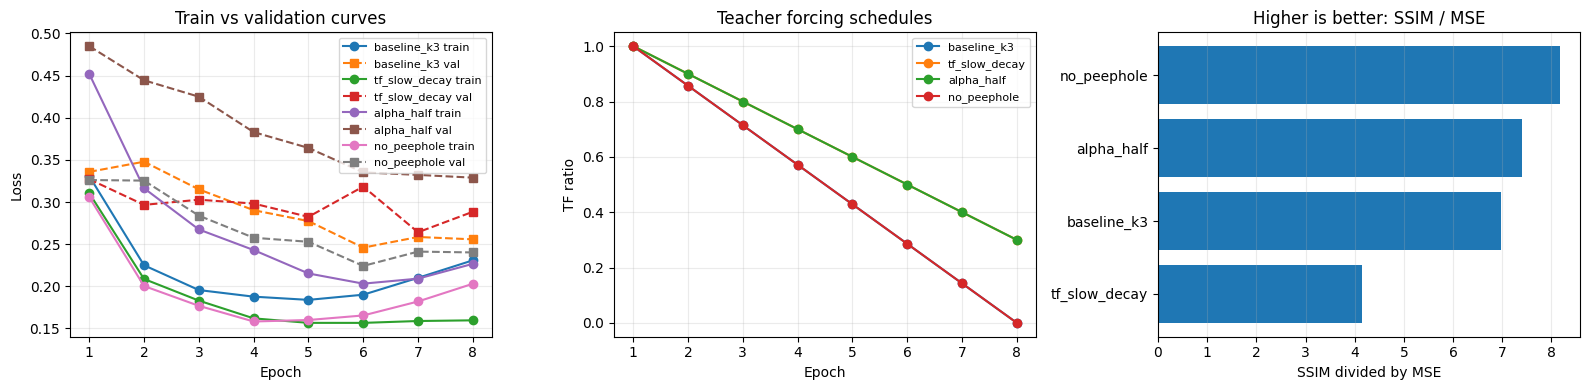

In [12]:

def plot_training_panel(experiments):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    for e in experiments:
        epochs = np.arange(1, len(e["history"]["train_loss"]) + 1)
        axes[0].plot(epochs, e["history"]["train_loss"], marker="o", label=f'{e["name"]} train')
        axes[0].plot(epochs, e["history"]["val_loss"], marker="s", linestyle="--", label=f'{e["name"]} val')
        axes[1].plot(epochs, e["history"]["tf_ratio"], marker="o", label=e["name"])

    rank = summary.copy()
    rank["score"] = rank["val_ssim"] / rank["val_mse"]
    rank = rank.sort_values("score", ascending=True)
    axes[2].barh(rank["name"], rank["score"])

    axes[0].set_title("Train vs validation curves")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=8)

    axes[1].set_title("Teacher forcing schedules")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("TF ratio")
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].grid(alpha=0.25)
    axes[1].legend(fontsize=8)

    axes[2].set_title("Higher is better: SSIM / MSE")
    axes[2].set_xlabel("SSIM divided by MSE")
    axes[2].grid(alpha=0.25, axis="x")

    plt.tight_layout()
    plt.show()

plot_training_panel(experiments)


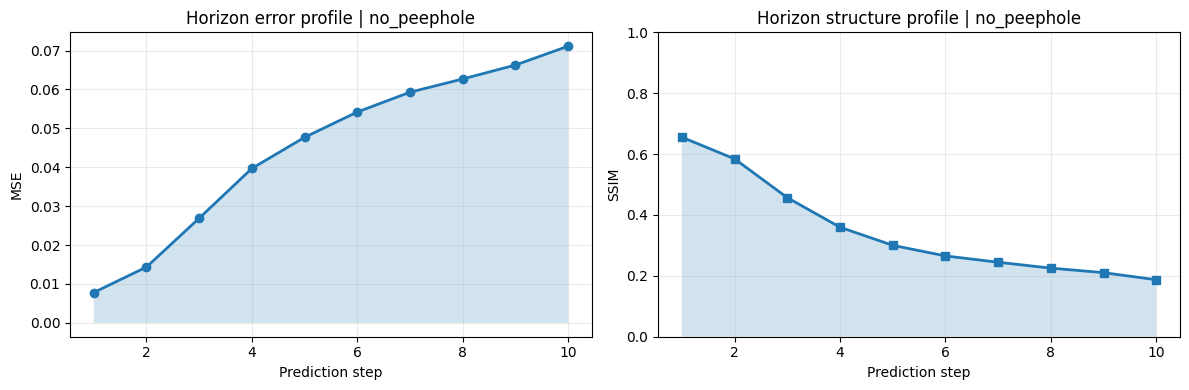

In [13]:

winner_model = best_exp["model"]
ts_mse, ts_ssim = per_timestep_metrics(winner_model, val_loader)
steps = np.arange(1, N_OUTPUT + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(steps, ts_mse, marker="o", linewidth=2)
axes[0].fill_between(steps, ts_mse, alpha=0.2)
axes[0].set_title(f"Horizon error profile | {best_exp['name']}")
axes[0].set_xlabel("Prediction step")
axes[0].set_ylabel("MSE")
axes[0].grid(alpha=0.25)

axes[1].plot(steps, ts_ssim, marker="s", linewidth=2)
axes[1].fill_between(steps, ts_ssim, alpha=0.2)
axes[1].set_title(f"Horizon structure profile | {best_exp['name']}")
axes[1].set_xlabel("Prediction step")
axes[1].set_ylabel("SSIM")
axes[1].set_ylim(0, 1.0)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


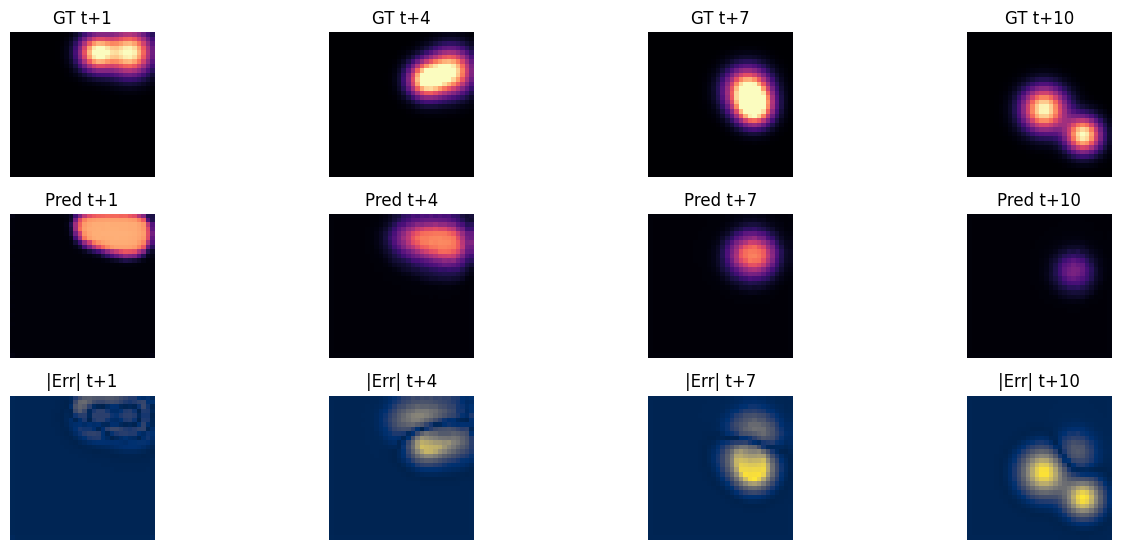

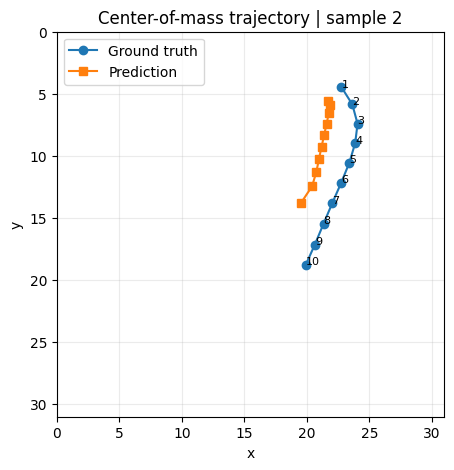

In [14]:

def predict_one(model, dataset, idx=0):
    x, y = dataset[idx]
    model.eval()
    with torch.no_grad():
        pred = model(x.unsqueeze(0).to(DEVICE), teacher_forcing_ratio=0.0)[0].cpu()
    return x, y, pred

def center_of_mass(frame):
    arr = frame.astype(np.float64)
    s = arr.sum()
    if s <= 1e-8:
        return np.nan, np.nan
    yy, xx = np.indices(arr.shape)
    cx = (xx * arr).sum() / s
    cy = (yy * arr).sum() / s
    return cx, cy

idx = 2
x, y, pred = predict_one(winner_model, val_ds, idx=idx)
err = (pred - y).abs()

sel = [0, 3, 6, 9]
fig, axes = plt.subplots(3, len(sel), figsize=(14, 5.6))
for j, t in enumerate(sel):
    axes[0, j].imshow(y[t, 0], cmap="magma", vmin=0, vmax=1)
    axes[0, j].set_title(f"GT t+{t+1}")
    axes[1, j].imshow(pred[t, 0], cmap="magma", vmin=0, vmax=1)
    axes[1, j].set_title(f"Pred t+{t+1}")
    axes[2, j].imshow(err[t, 0], cmap="cividis", vmin=0, vmax=float(err.max()))
    axes[2, j].set_title(f"|Err| t+{t+1}")
    for r in range(3):
        axes[r, j].axis("off")
axes[0, 0].set_ylabel("Ground truth")
axes[1, 0].set_ylabel("Prediction")
axes[2, 0].set_ylabel("Absolute error")
plt.tight_layout()
plt.show()

gt_xy = np.array([center_of_mass(y[t, 0].numpy()) for t in range(N_OUTPUT)])
pr_xy = np.array([center_of_mass(pred[t, 0].numpy()) for t in range(N_OUTPUT)])

plt.figure(figsize=(5, 5))
plt.plot(gt_xy[:, 0], gt_xy[:, 1], marker="o", label="Ground truth")
plt.plot(pr_xy[:, 0], pr_xy[:, 1], marker="s", label="Prediction")
for i in range(N_OUTPUT):
    plt.text(gt_xy[i, 0], gt_xy[i, 1], str(i + 1), fontsize=8)
plt.gca().invert_yaxis()
plt.xlim(0, IMG_SIZE - 1)
plt.ylim(IMG_SIZE - 1, 0)
plt.grid(alpha=0.25)
plt.title(f"Center-of-mass trajectory | sample {idx}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


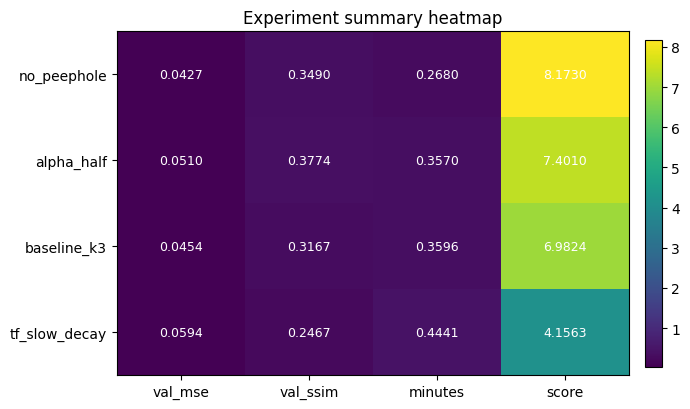

,name,val_mse,val_ssim,minutes,rank_score
0,no_peephole,0.042698,0.348966,0.268008,8.172954
1,alpha_half,0.050987,0.377354,0.356969,7.400995
2,baseline_k3,0.045361,0.316730,0.359555,6.982375
3,tf_slow_decay,0.059350,0.246676,0.444052,4.156298


In [15]:

metric_view = summary[["name", "val_mse", "val_ssim", "minutes"]].copy()
metric_view["rank_score"] = metric_view["val_ssim"] / metric_view["val_mse"]
metric_view = metric_view.sort_values("rank_score", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 2 + 0.55 * len(metric_view)))
heat = metric_view[["val_mse", "val_ssim", "minutes", "rank_score"]].to_numpy()
im = ax.imshow(heat, aspect="auto", cmap="viridis")
ax.set_xticks(range(4))
ax.set_xticklabels(["val_mse", "val_ssim", "minutes", "score"])
ax.set_yticks(range(len(metric_view)))
ax.set_yticklabels(metric_view["name"])
ax.set_title("Experiment summary heatmap")
for i in range(len(metric_view)):
    for j in range(4):
        ax.text(j, i, f"{heat[i, j]:.4f}", ha="center", va="center", color="white", fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.03)
plt.tight_layout()
plt.show()

metric_view


## Final full run

In [16]:

# After deciding the winner in fast mode:
# 1) set FAST_MODE = False in the first cell
# 2) rerun the notebook from the top
# 3) keep the final config below

FINAL_KERNEL = int(best_exp["kernel"])
FINAL_ALPHA = float(best_exp["alpha"])
FINAL_TF_END = float(best_exp["tf_end"])
FINAL_PEEPHOLE = bool(best_exp["peephole"])

print("Recommended final config")
print({
    "kernel": FINAL_KERNEL,
    "alpha": FINAL_ALPHA,
    "tf_start": 1.0,
    "tf_end": FINAL_TF_END,
    "peephole": FINAL_PEEPHOLE,
    "epochs": N_EPOCHS,
    "n_train": N_TRAIN,
    "n_val": N_VAL,
})

# Example for the final longer run:
# final_train_ds, final_val_ds, final_train_loader, final_val_loader = make_loaders()
# final_model = ConvLSTMModel(kernel_size=FINAL_KERNEL, n_output=N_OUTPUT, peephole=FINAL_PEEPHOLE).to(DEVICE)
# final_history, final_best_loss, final_minutes = train_model(
#     final_model, final_train_loader, final_val_loader,
#     n_epochs=N_EPOCHS, lr=LR, alpha=FINAL_ALPHA, tf_start=1.0, tf_end=FINAL_TF_END, tag="final_run"
# )
# final_mse, final_ssim = evaluate(final_model, final_val_loader)
# print(final_mse, final_ssim)


Recommended final config
{'kernel': 3, 'alpha': 0.7, 'tf_start': 1.0, 'tf_end': 0.0, 'peephole': False, 'epochs': 8, 'n_train': 200, 'n_val': 50}
